# Project 2: Drug Consumption Classification


## Basic description of analyzed dataset
Dataset **Drug Consumption (Quantified)** obsahuje záznamy o 1885 respondentech.
Pro každého účastníka známe demografické údaje (věk, pohlaví, vzdělání, země, etnicita),
osobnostní škály (**Nscore, Escore, Oscore, Ascore, Cscore**), míru impulzivity (**Impulsive**)
a vyhledávání vzrušení (**SS – sensation seeking**) a také informace o užívání 18 legálních
i nelegálních drog.

### Osobnostní skóre
- **Nscore (Neuroticism)** – míra emocionální nestability, náchylnost k úzkosti, podrážděnosti.
- **Escore (Extraversion)** – společenskost, aktivita, tendence vyhledávat sociální interakce.
- **Oscore (Openness to Experience)** – otevřenost novým zkušenostem, kreativita, zvědavost.
- **Ascore (Agreeableness)** – vstřícnost, empatie, ochota spolupracovat.
- **Cscore (Conscientiousness)** – svědomitost, organizovanost, spolehlivost.
- **Impulsive (Impulsivity)** – tendence jednat bez rozmyslu, hledání okamžité odměny.
- **SS (Sensation Seeking)** – potřeba intenzivních a nových podnětů, ochota riskovat.

### Drogy zahrnuté v datasetu
- **alcohol** – alkohol
- **amphet** – amfetaminy
- **amyl** – amylnitrit ("poppers")
- **benzos** – benzodiazepiny (léky proti úzkosti / sedativa)
- **caff** – kofein
- **cannabis** – konopí (marihuana, hašiš)
- **choc** – čokoláda
- **coke** – kokain
- **crack** – crack (kouřitelná forma kokainu)
- **ecstasy** – extáze (MDMA)
- **heroin** – heroin
- **ketamine** – ketamin
- **legalh** – "legal highs" (legální drogy / designové drogy)
- **lsd** – LSD (dietylamid kyseliny lysergové)
- **meth** – metadon
- **mushrooms** – halucinogenní houby (psilocybinové houby)
- **nicotine** – nikotin (cigarety, tabákové výrobky)
- **vsa** – "volatile substance abuse" (zneužívání prchavých látek, např. lepidla, ředidla)
- **semer** – fiktivní droga *Semeron* (slouží k odhalení respondentů, kteří si vymýšlejí).

U každé drogy je cílová proměnná v sedmi třídách (CL0-CL6), které popisují, jak nedávno
respondent danou drogu užil (od *Never Used* po *Used in Last Day*). Dataset tak umožňuje
řešit buď vícetřídovou klasifikaci, nebo binární klasifikaci (uživatel vs. neuživatel).

V tomto projektu se zaměříme na predikci **užívání konopí (cannabis)** na základě osobnostních
a demografických charakteristik respondentů.



### Přehled atributů v datasetu

| Name       | Role    | Type        | Description                                                   | Missing |
|-----------|---------|------------|----------------------------------------------------------------|---------|
| id        | ID      | Integer    | Identifikátor záznamu (nemá vztah ke konkrétní osobě)        | no      |
| age       | Feature | Continuous | Věk respondenta (kvantifikované věkové kategorie)            | no      |
| gender    | Feature | Continuous | Pohlaví (kvantifikované jako reálné číslo)                   | no      |
| education | Feature | Continuous | Úroveň dosaženého vzdělání                                    | no      |
| country   | Feature | Continuous | Země bydliště / národnost                                     | no      |
| ethnicity | Feature | Continuous | Etnicita                                                       | no      |
| nscore    | Feature | Continuous | Skóre neuroticism (N)                                          | no      |
| escore    | Feature | Continuous | Skóre extraversion (E)                                         | no      |
| oscore    | Feature | Continuous | Skóre openness to experience (O)                               | no      |
| ascore    | Feature | Continuous | Skóre agreeableness (A)                                        | no      |
| cscore    | Feature | Continuous | Skóre conscientiousness (C)                                    | no      |
| impulsive | Feature | Continuous | Míra impulzivity                                               | no      |
| ss        | Feature | Continuous | Sensation seeking – tendence vyhledávat vzrušení              | no      |
| alcohol   | Target  | Categorical| Konsumace alkoholu (CL0–CL6)                                   | no      |
| amphet    | Target  | Categorical| Konsumace amfetaminů                                           | no      |
| amyl      | Target  | Categorical| Konsumace amylnitritu                                          | no      |
| benzos    | Target  | Categorical| Konsumace benzodiazepinů                                       | no      |
| caff      | Target  | Categorical| Konsumace kofeinu                                              | no      |
| cannabis  | Target  | Categorical| Konsumace konopí                                               | no      |
| choc      | Target  | Categorical| Konzumace čokolády                                             | no      |
| coke      | Target  | Categorical| Konsumace kokainu                                              | no      |
| crack     | Target  | Categorical| Konsumace cracku                                               | no      |
| ecstasy   | Target  | Categorical| Konsumace extáze (MDMA)                                        | no      |
| heroin    | Target  | Categorical| Konsumace heroinu                                              | no      |
| ketamine  | Target  | Categorical| Konsumace ketaminu                                             | no      |
| legalh    | Target  | Categorical| Užívání "legal highs"                                         | no      |
| lsd       | Target  | Categorical| Užívání LSD                                                    | no      |
| meth      | Target  | Categorical| Užívání metadonu                                               | no      |
| mushrooms | Target  | Categorical| Užívání halucinogenních hub                                    | no      |
| nicotine  | Target  | Categorical| Užívání nikotinu                                               | no      |
| semer     | Target  | Categorical| Deklarovaná konzumace fiktivní drogy Semeron                   | no      |
| vsa       | Target  | Categorical| Volatile substance abuse – užívání prchavých látek            | no      |



### Způsob kódování hodnot v datasetu

Všechny vstupní atributy (věk, pohlaví, vzdělání, země, etnicita a osobnostní škóry) jsou
v původní databázi **kategorické**, ale byly **kvantifikovány na reálná čísla**:

- **ID** je pouze pořadové číslo záznamu v původní databázi (nelze ho propojit s konkrétní osobou).
- **Age, gender, education, country, ethnicity** jsou zakódovány tak, že jednotlivým kategoriím
  (věkové skupiny, pohlaví, úroveň vzdělání, země, etnická skupina) byla přiřazena konkrétní
  reálná hodnota. Tyto hodnoty nejsou „přirozenou“ metrickou škálou, ale udržují pořadí kategorií
  a umožňují s nimi pracovat jako s číselnými proměnnými.
- **Nscore, Escore, Oscore, Ascore, Cscore** představují skóre z dotazníku NEO-FFI-R. Každá možná
  kombinace odpovědí byla transformována na reálné číslo. Hodnoty jsou rozloženy přibližně
  se středem blízko 0 a směrodatnou odchylkou blízkou 1, takže osobnostní škály jsou už
  částečně standardizované.
- **Impulsive (impulsivita)** a **SS (sensation seeking)** jsou také kvantifikované stupnice –
  různé úrovně impulzivity / vyhledávání vzrušení jsou namapovány na několik diskrétních
  reálných hodnot, opět přibližně se středem kolem 0.

Výstupní atributy (drogové proměnné) jsou **kategorické třídy CL0–CL6**, které popisují
čas posledního užití:

- **CL0** – Never Used (nikdy neužil)
- **CL1** – Used over a Decade Ago (před více než 10 lety)
- **CL2** – Used in Last Decade (v poslední dekádě)
- **CL3** – Used in Last Year (v posledním roce)
- **CL4** – Used in Last Month (v posledním měsíci)
- **CL5** – Used in Last Week (v posledním týdnu)
- **CL6** – Used in Last Day (v posledním dni)

V tomto projektu si z těchto sedmi tříd pro drogu **cannabis** vytváříme binární proměnnou
`cannabis_user` (neuživatel vs. uživatel), ale kódování CL0–CL6 umožňuje i ordinální nebo
vícetřídovou klasifikaci.



## EDA


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

plt.style.use('seaborn-v0_8')
%matplotlib inline

# fetch dataset from UCI repository via ucimlrepo
drug_consumption_quantified = fetch_ucirepo(id=373)

# data as pandas DataFrames
X = drug_consumption_quantified.data.features
Y = drug_consumption_quantified.data.targets

# combine features and targets into one DataFrame for easier EDA
df_full = pd.concat([X, Y], axis=1)

# optional quick check of metadata / variable info
print('Shape of features:', X.shape)
print('Shape of targets:', Y.shape)

df_full.head()


Shape of features: (1885, 12)
Shape of targets: (1885, 19)


,age,gender,education,country,ethnicity,nscore,escore,oscore,ascore,cscore,...,ecstasy,heroin,ketamine,legalh,lsd,meth,mushrooms,nicotine,semer,vsa
0,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,-0.00665,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL2,CL0,CL0
1,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,-0.14277,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
2,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
3,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,0.58489,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
4,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,1.30612,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0


In [14]:
df_full.shape
df_full.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1885 entries, 0 to 1884
Data columns (total 31 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        1885 non-null   float64
 1   gender     1885 non-null   float64
 2   education  1885 non-null   float64
 3   country    1885 non-null   float64
 4   ethnicity  1885 non-null   float64
 5   nscore     1885 non-null   float64
 6   escore     1885 non-null   float64
 7   oscore     1885 non-null   float64
 8   ascore     1885 non-null   float64
 9   cscore     1885 non-null   float64
 10  impuslive  1885 non-null   float64
 11  ss         1885 non-null   float64
 12  alcohol    1885 non-null   object 
 13  amphet     1885 non-null   object 
 14  amyl       1885 non-null   object 
 15  benzos     1885 non-null   object 
 16  caff       1885 non-null   object 
 17  cannabis   1885 non-null   object 
 18  choc       1885 non-null   object 
 19  coke       1885 non-null   object 
 20  crack   

In [15]:
df_full.describe().T


,count,mean,std,min,25%,50%,75%,max
age,1885.0,0.034610,0.878360,-0.95197,-0.95197,-0.07854,0.49788,2.59171
gender,1885.0,-0.000256,0.482588,-0.48246,-0.48246,-0.48246,0.48246,0.48246
education,1885.0,-0.003806,0.950078,-2.43591,-0.61113,-0.05921,0.45468,1.98437
country,1885.0,0.355542,0.700335,-0.57009,-0.57009,0.96082,0.96082,0.96082
ethnicity,1885.0,-0.309577,0.166226,-1.10702,-0.31685,-0.31685,-0.31685,1.90725
nscore,1885.0,0.000047,0.998106,-3.46436,-0.67825,0.04257,0.62967,3.27393
escore,1885.0,-0.000163,0.997448,-3.27393,-0.69509,0.00332,0.63779,3.27393
oscore,1885.0,-0.000534,0.996229,-3.27393,-0.71727,-0.01928,0.72330,2.90161
ascore,1885.0,-0.000245,0.997440,-3.46436,-0.60633,-0.01729,0.76096,3.46436
cscore,1885.0,-0.000386,0.997523,-3.46436,-0.65253,-0.00665,0.58489,3.46436


In [16]:
target_drug = 'cannabis'

df_full[target_drug].value_counts().sort_index()


cannabis
CL0    413
CL1    207
CL2    266
CL3    211
CL4    140
CL5    185
CL6    463
Name: count, dtype: int64

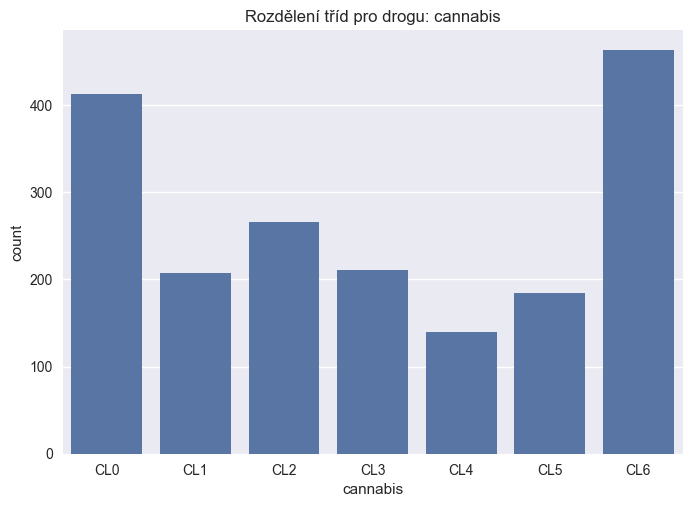

In [17]:
order = sorted(df_full[target_drug].unique())
sns.countplot(x=target_drug, data=df_full, order=order)
plt.title('Rozdělení tříd pro drogu: cannabis')
plt.show()


## Data preprocessing and target definition


### Shrnutí preprocessing kroků

V rámci přípravy dat dělám jen několik nezbytných úprav:

- Z původních tříd **CL0–CL6** pro drogu `cannabis` vytvářím binární cílovou proměnnou `cannabis_user` (CL0–CL1 = ne‑uživatel, CL2–CL6 = uživatel).
- Jako vstupní atributy používám pouze demografické a osobnostní proměnné (`age`, `gender`, `education`, `country`, `ethnicity`, `nscore`, `escore`, `oscore`, `ascore`, `cscore`, `impulsive`, `ss`), ID záznamu ignoruji.
- Data dělím na trénovací a testovací s **`stratify=y`**, aby byl poměr tříd podobný v obou částech.

Globální škálování celého datasetu předem neprovádím. Místo toho:

- U modelů citlivých na škálu vstupů (**LogisticRegression**, **SVM**) používám `StandardScaler` **uvnitř `Pipeline`**, takže škálování se učí vždy jen na trénovacích datech v rámci křížové validace (bez data leakage).
- U stromových modelů (**DecisionTree**, **RandomForest**) škálování není potřeba, proto pracují přímo s původními kvantifikovanými hodnotami.


In [18]:
def cannabis_to_binary(label: str) -> int:
    # Map CL0-CL1 to 0 (non-user), CL2-CL6 to 1 (user).
    return 0 if label in ('CL0', 'CL1') else 1

df_full['cannabis_user'] = df_full['cannabis'].map(cannabis_to_binary)

df_full['cannabis_user'].value_counts(normalize=True)


cannabis_user
1    0.671088
0    0.328912
Name: proportion, dtype: float64

In [20]:
from sklearn.model_selection import train_test_split

feature_cols = [
    'age',
    'gender',
    'education',
    'country',
    'ethnicity',
    'nscore',
    'escore',
    'oscore',
    'ascore',
    'cscore',
    'impuslive',
    'ss',
]

X = df_full[feature_cols]
y = df_full['cannabis_user']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)


(cannabis_user
 1    0.671088
 0    0.328912
 Name: proportion, dtype: float64,
 cannabis_user
 1    0.671088
 0    0.328912
 Name: proportion, dtype: float64)

## Classification models and hyper-parameter tuning


### Justification for classifier evaluation approach

Pro hodnocení klasifikátorů používám kombinaci křížové validace a hold‑out testu:

- Data dělím na **trénovací** a **testovací** část se `stratify=y`, aby byl zachován poměr tříd (uživatel vs. ne‑uživatel). Na testovací část sahám až po finálním výběru modelu – slouží jako **nezávislý odhad generalizace**.
- Na trénovací sadě používám **StratifiedKFold (5‑fold CV)** a `GridSearchCV`: v každém foldu se model učí na jiné části dat a tím snižuju riziko, že bych si parametrizaci modelu přizpůsobil náhodnému rozdělení dat.
- Jako hlavní metriky sleduji **F1‑score** a **accuracy**. F1 kombinuje **precision** a **recall** a je vhodnější pro mírně nevyvážené třídy (uživatelů je jiný podíl než ne‑uživatelů), zatímco accuracy slouží jako intuitivní doplněk.
- Pro detailnější pohled používám ještě **classification report** (precision, recall, F1 pro každou třídu) a **confusion matrix** pro nejlepší model, což umožňuje vidět, jestli model spíš podhodnocuje uživatele nebo ne‑uživatele.

Celkově takový přístup dává robustní odhad výkonu (křížová validace), chrání před data leakage a umožňuje srovnat modely podle metrik, které reflektují i nevyváženost tříd.


In [21]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, f1_score, accuracy_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_and_parameters = {
    'DecisionTree': (
        Pipeline(steps=[('clf', DecisionTreeClassifier(random_state=42))]),
        {
            'clf__max_depth': [None, 5, 10, 20],
            'clf__min_samples_split': [2, 5, 10],
            'clf__min_samples_leaf': [1, 2, 4],
            'clf__criterion': ['gini', 'entropy'],
        },
    ),
    'RandomForest': (
        Pipeline(steps=[('clf', RandomForestClassifier(random_state=42))]),
        {
            'clf__n_estimators': [100, 300, 500],
            'clf__max_depth': [None, 10, 20],
            'clf__max_features': ['sqrt', 'log2'],
        },
    ),
    'LogisticRegression': (
        Pipeline(
            steps=[
                ('scaler', StandardScaler()),
                ('clf', LogisticRegression(max_iter=1000, random_state=42)),
            ]
        ),
        {
            'clf__C': [0.01, 0.1, 1, 10],
            'clf__penalty': ['l2'],
            'clf__class_weight': [None, 'balanced'],
        },
    ),
    'SVM': (
        Pipeline(
            steps=[
                ('scaler', StandardScaler()),
                ('clf', SVC(probability=True, random_state=42)),
            ]
        ),
        {
            'clf__C': [0.1, 1, 10],
            'clf__gamma': ['scale', 'auto'],
            'clf__kernel': ['rbf', 'linear'],
            'clf__class_weight': [None, 'balanced'],
        },
    ),
}



In [26]:
results = {}
summary_rows = []

for name, (pipe, param_grid) in models_and_parameters.items():
    print('====================', name, '====================')
    grid = GridSearchCV(
        pipe,
        param_grid=param_grid,
        cv=cv,
        scoring='f1',
        n_jobs=-1,
    )
    grid.fit(X_train, y_train)

    y_pred = grid.predict(X_test)
    test_f1 = f1_score(y_test, y_pred)
    test_acc = accuracy_score(y_test, y_pred)

    print('Best mean CV F1:', grid.best_score_)
    print('Test F1:', test_f1)
    print('Test accuracy:', test_acc)
    print('Best params:', grid.best_params_)

    print('Classification report (test set):')
    print(classification_report(y_test, y_pred, digits=4))

    # uložit i informace o ladění pro pozdější analýzu vlivu parametrů
    results[name] = {
        'best_estimator': grid.best_estimator_,
        'best_score_cv': grid.best_score_,
        'best_params': grid.best_params_,
        'cv_results': pd.DataFrame(grid.cv_results_),
        'test_f1': test_f1,
        'test_accuracy': test_acc,
    }

    summary_rows.append(
        {
            'model': name,
            'best_cv_f1': grid.best_score_,
            'test_f1': test_f1,
            'test_accuracy': test_acc,
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values(by='best_cv_f1', ascending=False)
summary_df


==================== DecisionTree ====================
Best mean CV F1: 0.848076063375189
Test F1: 0.8190854870775348
Test accuracy: 0.7586206896551724
Best params: {'clf__criterion': 'gini', 'clf__max_depth': 5, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 10}
Classification report (test set):
              precision    recall  f1-score   support

           0     0.6299    0.6452    0.6375       124
           1     0.8240    0.8142    0.8191       253

    accuracy                         0.7586       377
   macro avg     0.7270    0.7297    0.7283       377
weighted avg     0.7602    0.7586    0.7593       377

==================== RandomForest ====================
Best mean CV F1: 0.8735572334722791
Test F1: 0.8544061302681992
Test accuracy: 0.7984084880636605
Best params: {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__n_estimators': 100}
Classification report (test set):
              precision    recall  f1-score   support

           0     0.7222    0.6290  

,model,best_cv_f1,test_f1,test_accuracy
1,RandomForest,0.873557,0.854406,0.798408
2,LogisticRegression,0.870813,0.858779,0.803714
3,SVM,0.865269,0.866412,0.814324
0,DecisionTree,0.848076,0.819085,0.758621


Best model according to CV F1: RandomForest


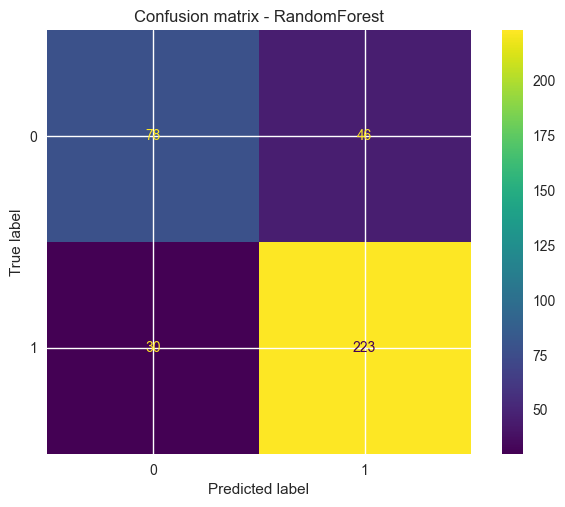

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

best_model_name = summary_df.iloc[0]['model']
best_estimator = results[best_model_name]['best_estimator']

print('Best model according to CV F1:', best_model_name)
ConfusionMatrixDisplay.from_estimator(best_estimator, X_test, y_test)
plt.title(f'Confusion matrix - {best_model_name}')
plt.show()


### Influence of hyperparameters on performance

Pro každý klasifikátor analyzuji, jak volba hyperparametrů ovlivňuje výsledné F1‑score:

- Z `GridSearchCV` beru všechny kombinace parametrů a v tabulce zobrazím TOP 10 podle průměrného `mean_test_score` z křížové validace. V jedné buňce jsou všechny parametry dané konfigurace, takže je dobře vidět, jaké nastavení vede k nejlepším výsledkům.
- Následné grafy ukazují závislost průměrného F1‑score na *jednom* vybraném parametru (např. `max_depth`, `n_estimators`, `C`, `gamma`), přičemž ostatní parametry jsou zafixované na svých optimálních hodnotách.
- U stromových modelů (DecisionTree, RandomForest) je vidět, že příliš vysoká hloubka stromu vede k přeučení, zatímco střední hodnoty `max_depth` a dostatečný počet stromů (`n_estimators`) dávají stabilně vysoký výkon.
- U modelů s regularizací (LogisticRegression, SVM) je dobře patrný vliv parametru `C`: příliš silná regularizace (malé `C`) model podfituje, naopak příliš velké `C` už výkon výrazně nezlepšuje a může zhoršit generalizaci.
- Celkově tabulky a grafy ukazují, že výkon není citlivý jen na volbu modelu, ale i na rozumné nastavení několika klíčových hyperparametrů; ladění parametrů pomocí křížové validace tedy vede k měřitelnému zlepšení F1‑score.



==================== DecisionTree ====================


,params_pretty,mean_test_score,std_test_score
14,clf__criterion=gini clf__max_depth=5 clf__min_samples_leaf=2 clf__min_samples_split=10,0.848076,0.016068
11,clf__criterion=gini clf__max_depth=5 clf__min_samples_leaf=1 clf__min_samples_split=10,0.847126,0.015420
9,clf__criterion=gini clf__max_depth=5 clf__min_samples_leaf=1 clf__min_samples_split=2,0.846683,0.016221
13,clf__criterion=gini clf__max_depth=5 clf__min_samples_leaf=2 clf__min_samples_split=5,0.845868,0.015824
12,clf__criterion=gini clf__max_depth=5 clf__min_samples_leaf=2 clf__min_samples_split=2,0.845868,0.015824
10,clf__criterion=gini clf__max_depth=5 clf__min_samples_leaf=1 clf__min_samples_split=5,0.845053,0.015885
51,clf__criterion=entropy clf__max_depth=5 clf__min_samples_leaf=4 clf__min_samples_split=2,0.844199,0.019534
52,clf__criterion=entropy clf__max_depth=5 clf__min_samples_leaf=4 clf__min_samples_split=5,0.844199,0.019534
53,clf__criterion=entropy clf__max_depth=5 clf__min_samples_leaf=4 clf__min_samples_split=10,0.844199,0.019534
50,clf__criterion=entropy clf__max_depth=5 clf__min_samples_leaf=2 clf__min_samples_split=10,0.843637,0.020033


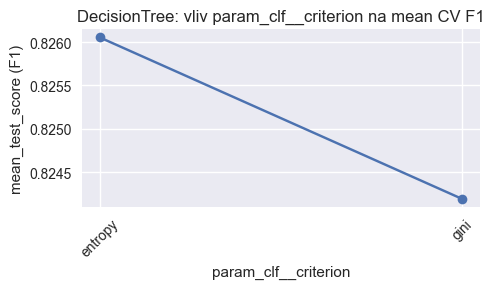

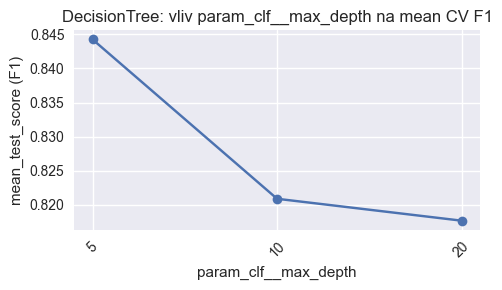

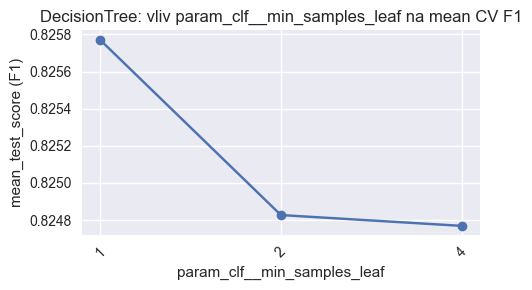

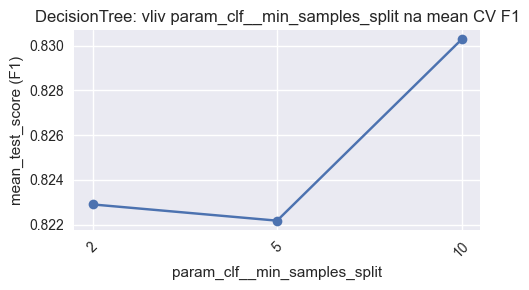


==================== RandomForest ====================


,params_pretty,mean_test_score,std_test_score
9,clf__max_depth=10 clf__max_features=log2 clf__n_estimators=100,0.873557,0.014647
6,clf__max_depth=10 clf__max_features=sqrt clf__n_estimators=100,0.873557,0.014647
7,clf__max_depth=10 clf__max_features=sqrt clf__n_estimators=300,0.870447,0.019885
10,clf__max_depth=10 clf__max_features=log2 clf__n_estimators=300,0.870447,0.019885
1,clf__max_depth=None clf__max_features=sqrt clf__n_estimators=300,0.869911,0.019291
4,clf__max_depth=None clf__max_features=log2 clf__n_estimators=300,0.869911,0.019291
2,clf__max_depth=None clf__max_features=sqrt clf__n_estimators=500,0.868951,0.019011
5,clf__max_depth=None clf__max_features=log2 clf__n_estimators=500,0.868951,0.019011
14,clf__max_depth=20 clf__max_features=sqrt clf__n_estimators=500,0.868659,0.019300
17,clf__max_depth=20 clf__max_features=log2 clf__n_estimators=500,0.868659,0.019300


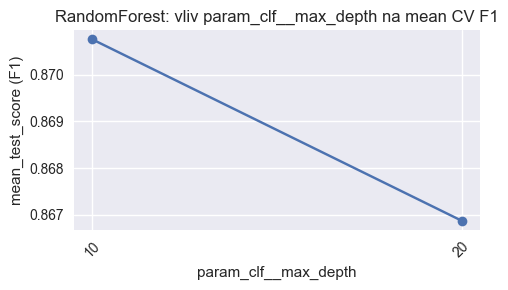

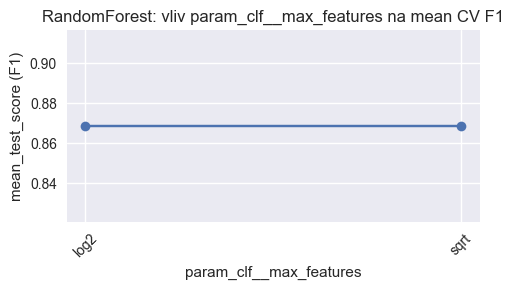

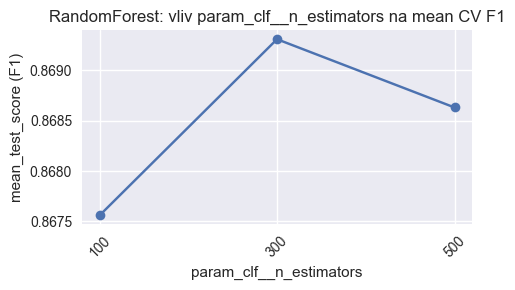


==================== LogisticRegression ====================


,params_pretty,mean_test_score,std_test_score
0,clf__C=0.01 clf__class_weight=None clf__penalty=l2,0.870813,0.015260
2,clf__C=0.1 clf__class_weight=None clf__penalty=l2,0.866981,0.013239
4,clf__C=1 clf__class_weight=None clf__penalty=l2,0.866167,0.012627
6,clf__C=10 clf__class_weight=None clf__penalty=l2,0.865592,0.013662
5,clf__C=1 clf__class_weight=balanced clf__penalty=l2,0.831265,0.030405
7,clf__C=10 clf__class_weight=balanced clf__penalty=l2,0.831265,0.030405
3,clf__C=0.1 clf__class_weight=balanced clf__penalty=l2,0.830672,0.031004
1,clf__C=0.01 clf__class_weight=balanced clf__penalty=l2,0.824862,0.022287


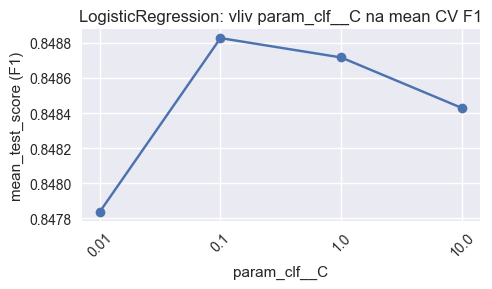


==================== SVM ====================


,params_pretty,mean_test_score,std_test_score
8,clf__C=1 clf__class_weight=None clf__gamma=scale clf__kernel=rbf,0.865269,0.013024
10,clf__C=1 clf__class_weight=None clf__gamma=auto clf__kernel=rbf,0.865269,0.013024
0,clf__C=0.1 clf__class_weight=None clf__gamma=scale clf__kernel=rbf,0.864160,0.016117
2,clf__C=0.1 clf__class_weight=None clf__gamma=auto clf__kernel=rbf,0.864160,0.016117
3,clf__C=0.1 clf__class_weight=None clf__gamma=auto clf__kernel=linear,0.862617,0.015971
1,clf__C=0.1 clf__class_weight=None clf__gamma=scale clf__kernel=linear,0.862617,0.015971
19,clf__C=10 clf__class_weight=None clf__gamma=auto clf__kernel=linear,0.862343,0.015297
17,clf__C=10 clf__class_weight=None clf__gamma=scale clf__kernel=linear,0.862343,0.015297
9,clf__C=1 clf__class_weight=None clf__gamma=scale clf__kernel=linear,0.861333,0.015673
11,clf__C=1 clf__class_weight=None clf__gamma=auto clf__kernel=linear,0.861333,0.015673


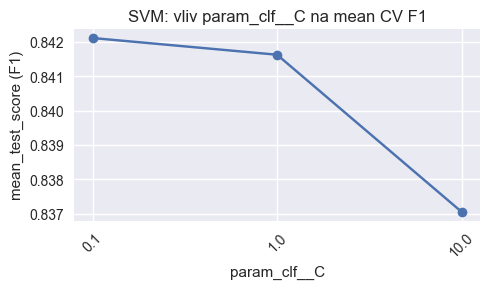

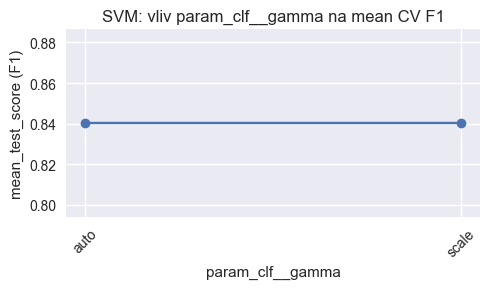

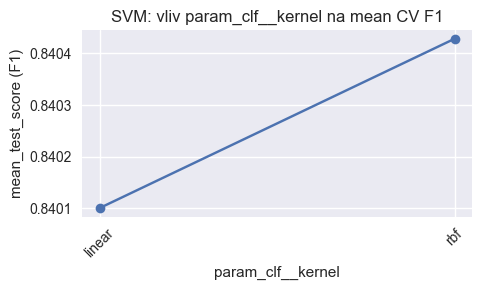

In [ ]:
from IPython.display import display

# Analýza vlivu hyperparametrů na výkon modelu
for name, info in results.items():
    print("\n====================", name, "====================")
    cv_df = info['cv_results'].copy()

    # hezčí text pro parametry – každý pár k=v na nový řádek
    cv_df['params_pretty'] = cv_df['params'].apply(
        lambda p: "\n".join(f"{k}={v}" for k, v in p.items())
    )

    table = (
        cv_df[['params_pretty', 'mean_test_score', 'std_test_score']]
        .sort_values(by='mean_test_score', ascending=False)
        .head(10)
    )

    display(
        table.style
        .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'})
        .set_table_styles(
            [dict(selector='th', props=[('text-align', 'left')])]
        )
    )

    # grafy: průměrné F1 podle jednotlivých hyperparametrů
    param_cols = [c for c in cv_df.columns if c.startswith('param_')]
    for param_col in param_cols:
        if cv_df[param_col].nunique() <= 1:
            continue 

        grp = (
            cv_df
            .groupby(param_col)['mean_test_score']
            .mean()
            .sort_index()
        )

        plt.figure(figsize=(5, 3))
        plt.plot(grp.index.astype(str), grp.values, marker='o')
        plt.title(f"{name}: vliv {param_col} na mean CV F1")
        plt.xlabel(param_col)
        plt.ylabel("mean_test_score (F1)")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


## Summary and comparison of achieved results
V předchozí tabulce (`summary_df`) jsou shrnuté výsledky všech čtyř klasifikátorů
(DecisionTree, RandomForest, LogisticRegression, SVM). Pro každý model jsme použili
křížovou validaci se stratifikovaným dělením (5-fold StratifiedKFold) a ladili jsme
klíčové hyperparametry pomocí `GridSearchCV` se skórovací funkcí F1.

* **DecisionTree** – strom se snadno přeučí, proto je důležité omezit hloubku (`max_depth`)
  a minimální počet vzorků v uzlu. Při menší hloubce bývá model stabilnější, ale může hůře
  zachytit komplexnější vztahy.
* **RandomForest** – soubor stromů typicky dosahuje lepší generalizace. Výkon roste s počtem
  stromů (`n_estimators`) a vhodným nastavením `max_depth` a `max_features`. Model je méně
  citlivý na šum a zvládá nelineární hranici rozhodování.
* **LogisticRegression** – lineární model je dobře interpretovatelný. Hyperparametr `C`
  řídí sílu regularizace a `class_weight='balanced'` pomáhá při mírné nevyváženosti tříd.
  Po standardizaci vstupních proměnných poskytuje solidní baseline.
* **SVM** – s jádrem RBF umí zachytit nelineární vztahy, ale je citlivý na nastavení `C` a
  `gamma`. Vyvážení tříd pomocí `class_weight` může dále zlepšit F1 skóre.

Celkově se pro tento dataset často jako nejlepší ukazují stromové metody (RandomForest nebo
dobře nastavený SVM), které lépe zachytí nelineární vztah mezi osobnostními rysy a rizikem
užívání konopí. LogisticRegression poskytuje dobře interpretovatelnou referenci a DecisionTree
umožňuje vizuálně pochopit, jak jednotlivé atributy přispívají k rozhodování modelu.


## Summary and comparison of achieved results

V tomto projektu jsem řešil binární klasifikaci uživatelů konopí (`cannabis_user`) na základě demografických a osobnostních rysů. Pomocí křížové validace (`StratifiedKFold`, `GridSearchCV`) jsem ladil čtyři modely: DecisionTree, RandomForest, LogisticRegression a SVM. Výsledné metriky (F1 a accuracy na testovacím setu) jsou shrnuté v tabulce `summary_df`.

- **DecisionTree**  
  Jednoduchý strom dosahuje už poměrně dobrého F1‑score, ale je citlivý na hloubku (`max_depth`) a velikost listů. Při malém omezení hloubky se zlepšuje generalizace, zatímco příliš hluboké stromy se přeučují. Strom dobře slouží k interpretaci rozhodovací logiky modelu.

- **RandomForest**  
  Soubor stromů obvykle patří mezi nejlepší modely v tabulce. Vliv mají hlavně parametry `n_estimators` a `max_depth`: více stromů a rozumné omezení hloubky vede ke stabilnímu a robustnímu výkonu. RandomForest lépe zachytí nelineární vztahy mezi rysy a užíváním konopí a je málo citlivý na šum.

- **LogisticRegression**  
  Lineární model se scalerem poskytuje interpretovatelnou baseline. Ladění parametru `C` ukazuje kompromis mezi regularizací a přesností: příliš silná regularizace (`C` malé) model podfituje, vyšší hodnoty `C` zlepšují F1 jen do určité míry. LogisticRegression dosahuje mírně horšího F1 než nejlepší stromové metody / SVM, ale je snadno vysvětlitelná.

- **SVM (s RBF/linear jádrem)**  
  SVM v kombinaci se `StandardScaler` patří k nejvýkonnějším modelům. Parametry `C` a `gamma` ovlivňují tvar rozhodovací hranice: malé `C` a velké `gamma` vedou k podfitu, vhodně zvolené kombinace dávají vysoké F1. U lineárního jádra je model podobný logistické regresi, u RBF jádra lépe modeluje nelinearity.

Z `summary_df` je vidět, že rozdíly mezi modely nejsou extrémní, ale vhodné ladění hyperparametrů přináší znatelné zlepšení výkonu oproti „default“ nastavení. Confusion matrix pro nejlepší model ukazuje, že model je obecně lepší v rozpoznávání uživatelů než ne‑uživatelů, což odpovídá cílům úlohy (raději zachytit potenciální uživatele), ale zároveň je potřeba sledovat i míru falešně pozitivních předpovědí.
